In [15]:
# ==========================================
# PASSO 1: Instalação de Dependências e Setup
# ==========================================
!pip install -q kagglehub grad-cam matplotlib seaborn scikit-learn tensorflow

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- CONFIGURAÇÃO DE DETERMINISMO (REPRODUTIBILIDADE) ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Habilita determinismo estrito no TensorFlow/GPU
tf.config.experimental.enable_op_determinism()

# Verificar se GPU está ativa
print("TensorFlow Version:", tf.version.VERSION)
print("GPU Disponível:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
# ==========================================
# PASSO 2: Download do Dataset (BUSI - Breast Ultrasound Images)
# ==========================================
import kagglehub

# Baixa o dataset oficial de imagens de ultrassom de mama
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Caminho do Dataset baixado:", path)

# Mapeando os diretórios dentro da pasta baixada
dataset_dir = path
if os.path.exists(os.path.join(path, "Dataset_BUSI_AN")):
    dataset_dir = os.path.join(path, "Dataset_BUSI_AN")

print("Conteúdo da pasta do dataset:", os.listdir(dataset_dir))

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Caminho do Dataset baixado: /kaggle/input/breast-ultrasound-images-dataset
Conteúdo da pasta do dataset: ['Dataset_BUSI_with_GT']


Total de imagens originais encontradas: 780

Distribuição de imagens por classe:
       label  count
0     benign    437
1  malignant    210
2     normal    133


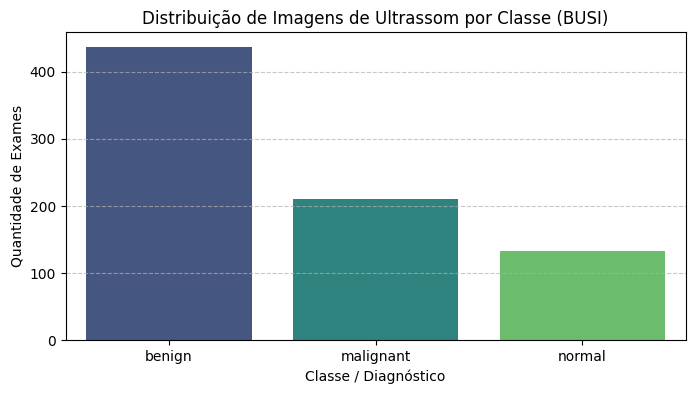

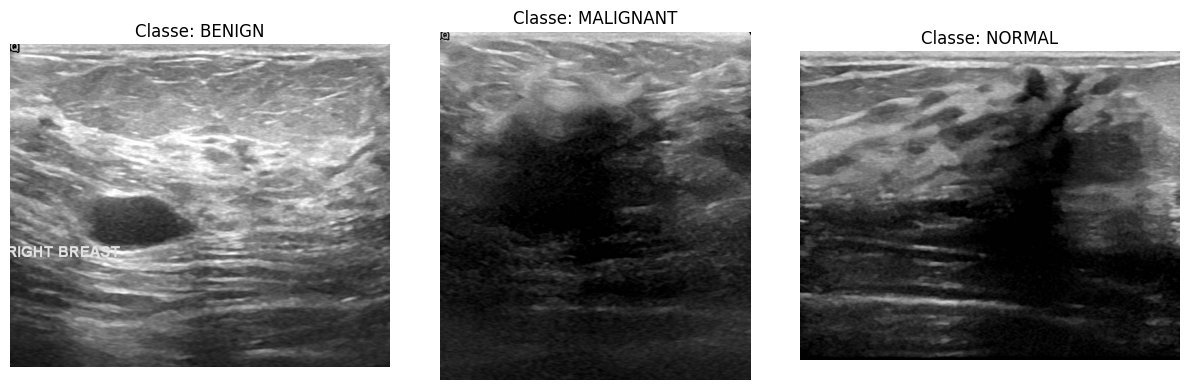

In [17]:
# ==========================================
# PASSO 3: Mapeamento dos Arquivos e EDA das Imagens
# ==========================================
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

# Definição do caminho exato retornado no Passo 2
busi_path = os.path.join(dataset_dir, "Dataset_BUSI_with_GT")

image_paths = []
labels = []
categories = ['benign', 'malignant', 'normal']

for category in categories:
    folder_path = os.path.join(busi_path, category)
    if os.path.exists(folder_path):
        # Seleciona todos os arquivos .png da categoria
        all_files = glob.glob(os.path.join(folder_path, "*.png"))

        # Filtra removendo os arquivos de máscara (_mask.png)
        original_images = [f for f in all_files if "_mask" not in f]

        for img_p in original_images:
            image_paths.append(img_p)
            labels.append(category)

# Criar DataFrame com os caminhos e rótulos
df = pd.DataFrame({
    'filepath': image_paths,
    'label': labels
})

print(f"Total de imagens originais encontradas: {len(df)}")
print("\nDistribuição de imagens por classe:")
print(df['label'].value_counts().reset_index())

# Gráfico de barras com a distribuição das classes (Corrigido para evitar o warning)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribuição de Imagens de Ultrassom por Classe (BUSI)')
plt.xlabel('Classe / Diagnóstico')
plt.ylabel('Quantidade de Exames')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Exibir 1 amostra de cada classe
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, cat in enumerate(categories):
    sample_path = df[df['label'] == cat]['filepath'].iloc[0]
    img = Image.open(sample_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"Classe: {cat.upper()}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# PASSO 4: Data Split Stratified & Data Augmentation
# ==========================================
from sklearn.model_selection import train_test_split

# Split 1: Separa 70% para Treino e 30% para Validação + Teste
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label']
)

# Split 2: Divide os 30% restantes em 15% Validação e 15% Teste
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print(f"Total Treino: {len(train_df)}")
print(f"Total Validação: {len(val_df)}")
print(f"Total Teste: {len(test_df)}")

# Configurações globais
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation para Treino (com semente fixa)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Apenas reescalonamento para Validação e Teste
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow From DataFrame (Fixando a semente no train_generator)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Total Treino: 546
Total Validação: 117
Total Teste: 117
Found 546 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.


In [19]:
# ==========================================
# PASSO 5: Construção e Treinamento da CNN
# ==========================================

# 1. Carregar a base MobileNetV2 sem o topo (sem as camadas de classificação originais)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar os pesos do modelo base
base_model.trainable = False

# 2. Adicionar o cabeçalho de classificação customizado
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(3, activation='softmax')(x) # 3 classes: benign, malignant, normal

# Criar o modelo final
model = Model(inputs=base_model.input, outputs=predictions)

# 3. Compilar o modelo
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para controle de treinamento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# 5. Treinamento
EPOCHS = 25

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4853 - loss: 1.2562 - val_accuracy: 0.6752 - val_loss: 0.7540 - learning_rate: 0.0010
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 958ms/step - accuracy: 0.6154 - loss: 0.8277 - val_accuracy: 0.7094 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 741ms/step - accuracy: 0.6832 - loss: 0.7098 - val_accuracy: 0.7265 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6886 - loss: 0.7033 - val_accuracy: 0.7179 - val_loss: 0.5906 - learning_rate: 0.0010
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 814ms/step - accuracy: 0.7015 - loss: 0.6721 - val_accuracy: 0.7179 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6941 - loss: 0.7079 - val_accuracy: 0.7436 - val_loss: 0.5877 - learning_rate: 0.0010
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 820ms/step - accuracy: 0.7436 - loss: 0.6049 - va

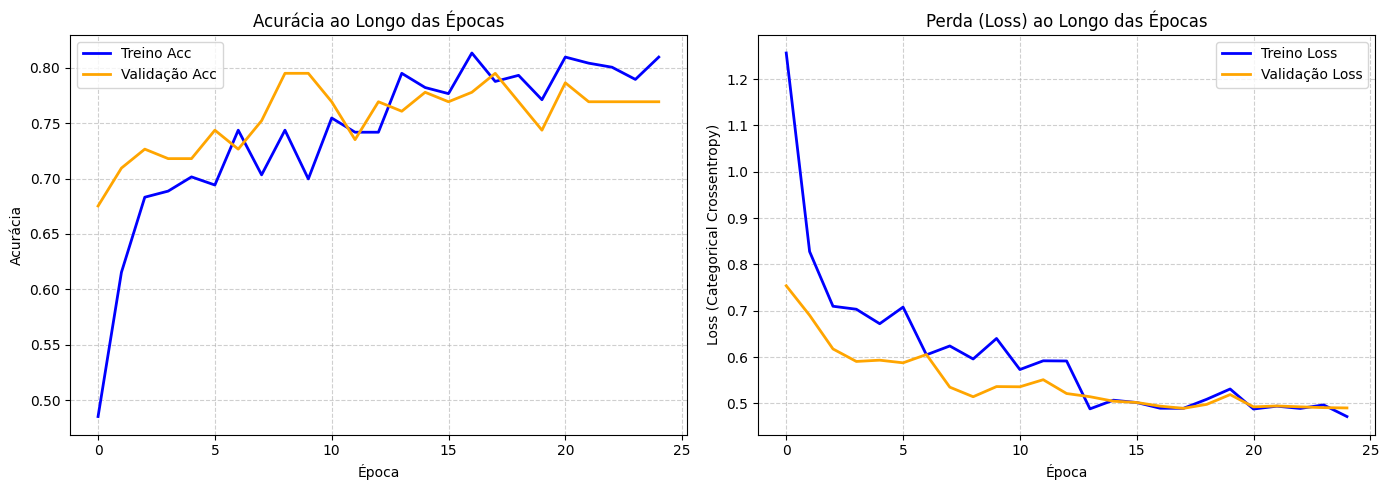

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 973ms/step

RELATÓRIO DE CLASSIFICAÇÃO (MÉTRICAS DE TESTE)
              precision    recall  f1-score   support

      benign       0.73      0.82      0.77        66
   malignant       0.62      0.58      0.60        31
      normal       0.71      0.50      0.59        20

    accuracy                           0.70       117
   macro avg       0.69      0.63      0.65       117
weighted avg       0.70      0.70      0.69       117



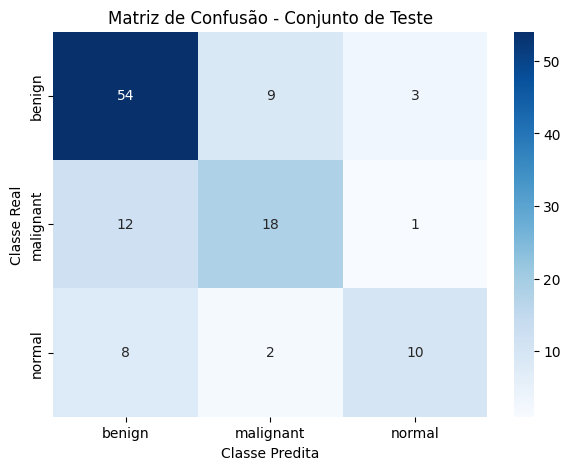

In [20]:
# ==========================================
# PASSO 6: Avaliação de Métricas e Curvas
# ==========================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gráficos das Curvas de Aprendizado (Loss e Accuracy)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino Acc', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação Acc', color='orange', linewidth=2)
plt.title('Acurácia ao Longo das Épocas', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação Loss', color='orange', linewidth=2)
plt.title('Perda (Loss) ao Longo das Épocas', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Predições no Conjunto de Teste
test_generator.reset()
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 3. Exibir Classification Report
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO (MÉTRICAS DE TESTE)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_labels))

# 4. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

--- Grad-CAM Exemplo: Lesão Maligna ---


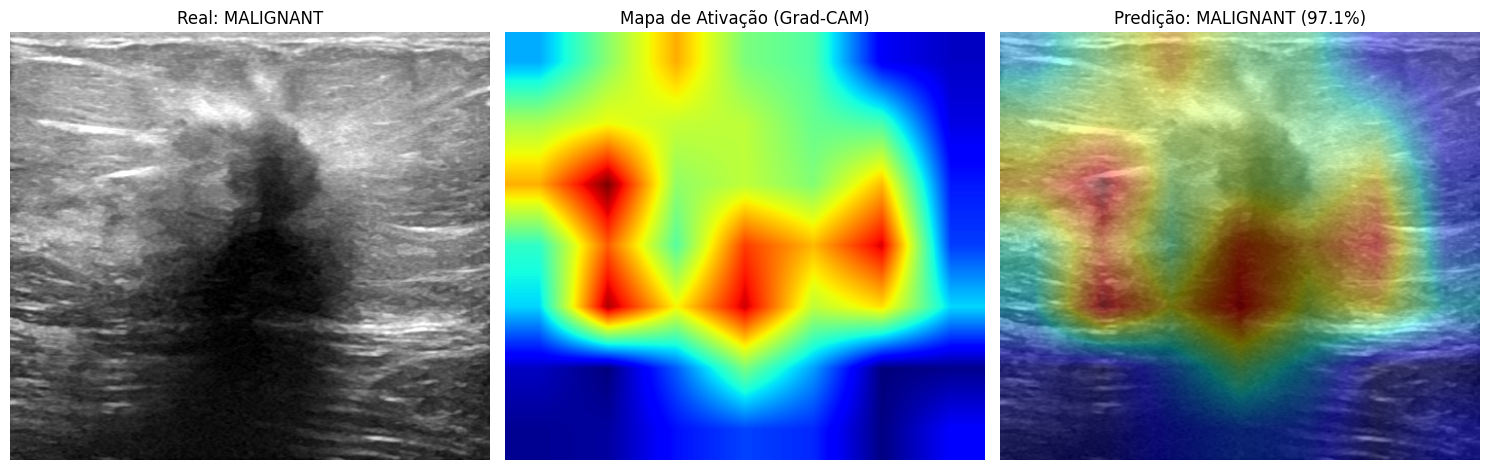

--- Grad-CAM Exemplo: Lesão Benigna ---


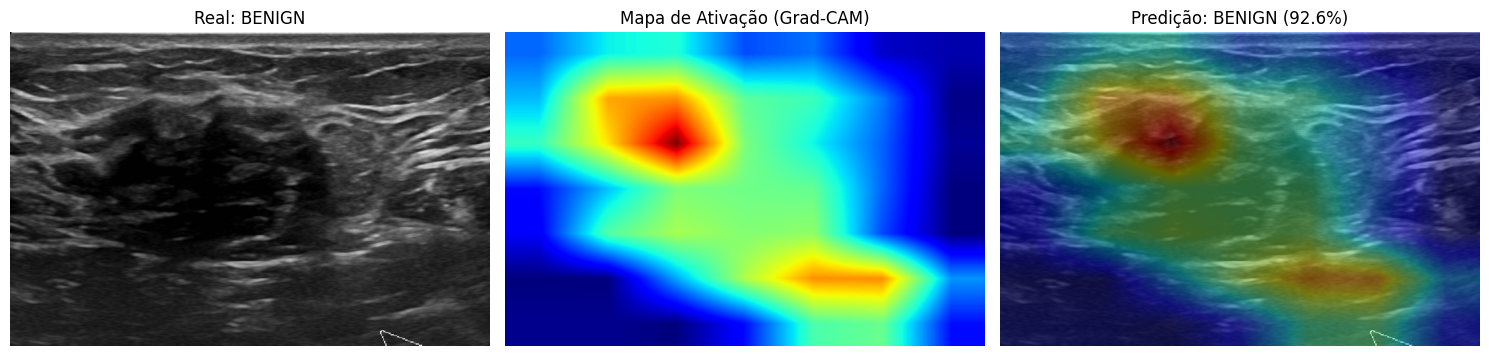


--- Salvando e Baixando o Modelo ---
Modelo salvo localmente como: mobilenetv2_busi_best.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ==========================================
# PASSO 7: Grad-CAM (Explicabilidade Visual) & Salvamento
# ==========================================
import cv2
import warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import files

# Ignorar o UserWarning de estrutura aninhada do Keras
warnings.filterwarnings('ignore', category=UserWarning)

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # Ajuste: uso de model.input sem colchetes para evitar o UserWarning
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradiente da classe predita em relação às ativações da última camada convolucional
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiplicação ponderada
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalização do heatmap entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def plot_gradcam_sample(model, df_sample, class_labels):
    # Seleciona a última camada convolucional da MobileNetV2
    last_conv_layer_name = "out_relu"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Carregar imagem e pré-processar
    img_path = df_sample['filepath']
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_original, (224, 224))
    img_tensor = np.expand_dims(img_resized / 255.0, axis=0)

    # Predição
    preds = model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = class_labels[pred_idx]
    confidence = preds[0][pred_idx] * 100

    # Gerar Heatmap
    heatmap = get_gradcam_heatmap(model, img_tensor, last_conv_layer_name, pred_idx)

    # Sobrepor Heatmap na Imagem Original
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cm.jet(heatmap_colored)[:, :, :3] # Colormap JET
    heatmap_colored = np.uint8(heatmap_colored * 255)

    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

    # Plotar resultados
    axes[0].imshow(img_original)
    axes[0].set_title(f"Real: {df_sample['label'].upper()}")
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Mapa de Ativação (Grad-CAM)")
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f"Predição: {pred_class.upper()} ({confidence:.1f}%)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Gerar exemplo Grad-CAM para 1 caso Maligno e 1 Benigno
labels_keys = list(test_generator.class_indices.keys())

sample_malignant = test_df[test_df['label'] == 'malignant'].iloc[0]
print("--- Grad-CAM Exemplo: Lesão Maligna ---")
plot_gradcam_sample(model, sample_malignant, labels_keys)

sample_benign = test_df[test_df['label'] == 'benign'].iloc[0]
print("--- Grad-CAM Exemplo: Lesão Benigna ---")
plot_gradcam_sample(model, sample_benign, labels_keys)

# ==========================================
# SALVAMENTO E DOWNLOAD DO MODELO
# ==========================================
print("\n--- Salvando e Baixando o Modelo ---")
model_filename = 'mobilenetv2_busi_best.keras'
model.save(model_filename)
print(f"Modelo salvo localmente como: {model_filename}")

# Inicia o download do arquivo no seu navegador
files.download(model_filename)